In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import tifffile as tiff
import xml.etree.ElementTree as ET

from skimage.draw import polygon
from skimage.segmentation import find_boundaries
from skimage.transform import resize

from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import remove_small_objects, h_maxima

import torch
import torch.nn.functional as F


In [3]:
# ---- A MODIFIER ----
MONUSEG_TEST_DIR = Path("data/monuseg/test")
UNET_CKPT = Path("models/checkpoints/unet_pannuke_lit_best.ckpt")
STARDIST_CKPT = Path("models/checkpoints/stardist_pannuke_best.ckpt")
# --------------------

assert MONUSEG_TEST_DIR.exists(), MONUSEG_TEST_DIR
print("MoNuSeg test:", MONUSEG_TEST_DIR)
print("UNet ckpt exists:", UNET_CKPT.exists(), UNET_CKPT)
print("StarDist ckpt exists:", STARDIST_CKPT.exists(), STARDIST_CKPT)


MoNuSeg test: data\monuseg\test
UNet ckpt exists: True models\checkpoints\unet_pannuke_lit_best.ckpt
StarDist ckpt exists: True models\checkpoints\stardist_pannuke_best.ckpt


In [4]:
def read_tif_rgb(path: Path) -> np.ndarray:
    img = tiff.imread(str(path))
    # img peut être (H,W,3) ou (3,H,W) selon les fichiers
    if img.ndim == 3 and img.shape[0] == 3 and img.shape[-1] != 3:
        img = np.transpose(img, (1,2,0))
    if img.ndim == 2:
        img = np.stack([img,img,img], axis=-1)
    img = img.astype(np.float32)
    # normalisation simple en [0,1]
    if img.max() > 1.0:
        img /= 255.0
    img = np.clip(img, 0, 1)
    return img  # (H,W,3) float32


In [5]:
def monuseg_xml_to_instances(xml_path: Path, H: int, W: int) -> np.ndarray:
    """
    Convertit les annotations XML MoNuSeg en masque d'instances (H,W) int32
    Chaque polygone devient une instance distincte.
    """
    tree = ET.parse(str(xml_path))
    root = tree.getroot()

    inst = np.zeros((H, W), dtype=np.int32)
    cur_id = 1

    # Les fichiers MoNuSeg ont souvent des "Region" / "Vertices" / "Vertex"
    # On prend tous les polygones trouvés.
    for region in root.iter():
        tag = region.tag.lower()
        if "region" in tag:
            # cherche des vertices
            verts = []
            for v in region.iter():
                if "vertex" in v.tag.lower():
                    x = v.attrib.get("X") or v.attrib.get("x")
                    y = v.attrib.get("Y") or v.attrib.get("y")
                    if x is None or y is None:
                        continue
                    verts.append((float(x), float(y)))

            if len(verts) >= 3:
                xs = np.array([p[0] for p in verts], dtype=np.float32)
                ys = np.array([p[1] for p in verts], dtype=np.float32)

                rr, cc = polygon(ys, xs, shape=(H, W))
                if len(rr) > 0:
                    inst[rr, cc] = cur_id
                    cur_id += 1

    return inst


In [6]:
def resize_img_and_inst(img: np.ndarray, inst: np.ndarray, out_hw=(256,256)):
    H, W = out_hw
    img_r = resize(img, (H, W, 3), preserve_range=True, anti_aliasing=True).astype(np.float32)
    # inst: nearest neighbor
    inst_r = resize(inst, (H, W), order=0, preserve_range=True, anti_aliasing=False).astype(np.int32)
    return img_r, inst_r


In [7]:
def unet_prob_to_instances(prob, thr=0.5, min_size=20, h=1.5):
    prob = prob.astype(np.float32)
    bin_mask = prob > thr
    bin_mask = remove_small_objects(bin_mask, min_size=min_size)

    if bin_mask.sum() == 0:
        return np.zeros_like(prob, dtype=np.int32)

    dist = ndi.distance_transform_edt(bin_mask)

    seeds = h_maxima(dist, h=h)
    seeds &= bin_mask

    markers, _ = ndi.label(seeds)
    if markers.max() == 0:
        markers, _ = ndi.label(bin_mask)

    labels = watershed(-dist, markers, mask=bin_mask)
    return labels.astype(np.int32)


In [8]:
def dice_iou_binary(pred_bin: np.ndarray, gt_bin: np.ndarray):
    pred = pred_bin.astype(bool)
    gt = gt_bin.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    p = pred.sum()
    g = gt.sum()
    dice = (2*inter) / (p+g+1e-8)
    iou = inter / (union+1e-8)
    return float(dice), float(iou)


In [9]:
def instance_iou_matrix(pred_inst: np.ndarray, gt_inst: np.ndarray):
    pred_ids = np.unique(pred_inst)
    gt_ids = np.unique(gt_inst)
    pred_ids = pred_ids[pred_ids > 0]
    gt_ids = gt_ids[gt_ids > 0]

    M = np.zeros((len(gt_ids), len(pred_ids)), dtype=np.float32)
    if len(gt_ids) == 0 or len(pred_ids) == 0:
        return M, gt_ids, pred_ids

    # accélération: index des pixels par label
    pred_masks = {pid: (pred_inst == pid) for pid in pred_ids}

    for i, gid in enumerate(gt_ids):
        gmask = (gt_inst == gid)
        gsum = gmask.sum()
        if gsum == 0:
            continue
        for j, pid in enumerate(pred_ids):
            pmask = pred_masks[pid]
            inter = np.logical_and(gmask, pmask).sum()
            union = gsum + pmask.sum() - inter
            if union > 0:
                M[i, j] = inter / union
    return M, gt_ids, pred_ids


In [10]:
def f1_instance(pred_inst: np.ndarray, gt_inst: np.ndarray, iou_thr=0.5):
    M, gt_ids, pred_ids = instance_iou_matrix(pred_inst, gt_inst)
    if M.size == 0:
        # aucun gt ou aucun pred
        TP = 0
        FP = len(pred_ids)
        FN = len(gt_ids)
        f1 = 0.0 if (2*TP+FP+FN) > 0 else 1.0
        return f1, TP, FP, FN

    # greedy matching: prend les meilleurs couples sans réutiliser
    pairs = []
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if M[i, j] >= iou_thr:
                pairs.append((M[i, j], i, j))
    pairs.sort(reverse=True, key=lambda x: x[0])

    used_gt = set()
    used_pr = set()
    TP = 0
    for score, i, j in pairs:
        if i in used_gt or j in used_pr:
            continue
        used_gt.add(i)
        used_pr.add(j)
        TP += 1

    FN = M.shape[0] - TP
    FP = M.shape[1] - TP
    f1 = (2*TP) / (2*TP + FP + FN + 1e-8)
    return float(f1), int(TP), int(FP), int(FN)


In [11]:
from models.unet import UNet
from models.stardist import StarDist, stardist_decode


In [12]:
def load_lightning_weights_into(model: torch.nn.Module, ckpt_path: Path, prefix="model."):
    ckpt = torch.load(str(ckpt_path), map_location="cpu")
    sd = ckpt["state_dict"] if "state_dict" in ckpt else ckpt

    # Lightning: clés souvent comme "model.xxx"
    new_sd = {}
    for k, v in sd.items():
        if k.startswith(prefix):
            new_sd[k[len(prefix):]] = v
        elif k.startswith("model."):
            new_sd[k[len("model."):]] = v
    missing, unexpected = model.load_state_dict(new_sd, strict=False)
    print("Loaded:", ckpt_path.name)
    print("Missing keys:", len(missing), "Unexpected keys:", len(unexpected))
    return model


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

unet = UNet(in_channels=3, out_channels=1, base_ch=64)
unet = load_lightning_weights_into(unet, UNET_CKPT).to(device).eval()


device: cuda
Loaded: unet_pannuke_lit_best.ckpt
Missing keys: 0 Unexpected keys: 0


In [16]:
stard = StarDist(input_ch=3, n_rays=32, base_ch=32)
stard = load_lightning_weights_into(stard, STARDIST_CKPT).to(device).eval()

RuntimeError: Error(s) in loading state_dict for StarDist:
	size mismatch for head_dist.weight: copying a param with shape torch.Size([64, 32, 1, 1]) from checkpoint, the shape in current model is torch.Size([32, 32, 1, 1]).
	size mismatch for head_dist.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for head_cls.weight: copying a param with shape torch.Size([6, 32, 1, 1]) from checkpoint, the shape in current model is torch.Size([7, 32, 1, 1]).
	size mismatch for head_cls.bias: copying a param with shape torch.Size([6]) from checkpoint, the shape in current model is torch.Size([7]).

In [13]:
@torch.no_grad()
def predict_unet_instances(img256: np.ndarray, thr=0.5, min_size=20, h=1.5):
    x = torch.from_numpy(img256).permute(2,0,1).unsqueeze(0).float().to(device)  # (1,3,256,256)
    logits = unet(x)[0,0].detach().cpu().numpy()
    prob = 1.0 / (1.0 + np.exp(-logits))
    inst = unet_prob_to_instances(prob, thr=thr, min_size=min_size, h=h)
    return prob.astype(np.float32), inst.astype(np.int32)


In [14]:
@torch.no_grad()
def predict_stardist_instances(img256: np.ndarray, prob_thr=0.5, nms_iou_thr=0.3, min_area=10, max_candidates=3000):
    x = torch.from_numpy(img256).permute(2,0,1).unsqueeze(0).float().to(device)
    out = stard(x)[0].detach().cpu().numpy()  # (1+R, H, W)

    prob_logits = out[0]
    prob = 1.0 / (1.0 + np.exp(-prob_logits))

    dist_map = out[1:].astype(np.float32)  # (R,H,W) déjà softplus dans ton modèle
    dist_map = np.maximum(dist_map, 0.0)

    inst = stardist_decode(
        prob_map=prob.astype(np.float32),
        dist_map=dist_map,
        prob_thr=prob_thr,
        nms_iou_thr=nms_iou_thr,
        use_local_maxima=True,
        local_max_footprint=3,
        max_candidates=max_candidates,
        min_area=min_area,
    )
    return prob.astype(np.float32), inst.astype(np.int32)


In [15]:
def overlay_contours(img, gt_inst, unet_inst=None, stard_inst=None, title=""):
    img = np.clip(img, 0, 1)
    vis = img.copy()

    def add_boundary(mask_inst, color):
        if mask_inst is None:
            return
        b = find_boundaries(mask_inst, mode="outer")
        vis[b] = color

    # GT en vert
    add_boundary(gt_inst, np.array([0,1,0], dtype=np.float32))
    # U-Net en rouge
    add_boundary(unet_inst, np.array([1,0,0], dtype=np.float32))
    # StarDist en bleu
    add_boundary(stard_inst, np.array([0,0,1], dtype=np.float32))

    plt.figure(figsize=(7,7))
    plt.imshow(vis)
    plt.title(title)
    plt.axis("off")
    plt.show()




In [16]:
tifs = sorted(MONUSEG_TEST_DIR.glob("*.tif"))
print("nb tifs:", len(tifs))
tifs[:5]


nb tifs: 14


[WindowsPath('data/monuseg/test/TCGA-2Z-A9J9-01A-01-TS1.tif'),
 WindowsPath('data/monuseg/test/TCGA-44-2665-01B-06-BS6.tif'),
 WindowsPath('data/monuseg/test/TCGA-69-7764-01A-01-TS1.tif'),
 WindowsPath('data/monuseg/test/TCGA-A6-6782-01A-01-BS1.tif'),
 WindowsPath('data/monuseg/test/TCGA-AC-A2FO-01A-01-TS1.tif')]

In [22]:
for p in tifs:
    xml = p.with_suffix(".xml")
    img = read_tif_rgb(p)
    gt = monuseg_xml_to_instances(xml, img.shape[0], img.shape[1])

    img256, gt256 = resize_img_and_inst(img, gt, (256,256))

    _, unet_inst = predict_unet_instances(img256, thr=0.5, min_size=20, h=1.5)
    _, st_inst = predict_stardist_instances(img256, prob_thr=0.5, nms_iou_thr=0.3)

    d_u, i_u = dice_iou_binary(unet_inst>0, gt256>0)
    f1_u, TP_u, FP_u, FN_u = f1_instance(unet_inst, gt256, iou_thr=0.5)

    d_s, i_s = dice_iou_binary(st_inst>0, gt256>0)
    f1_s, TP_s, FP_s, FN_s = f1_instance(st_inst, gt256, iou_thr=0.5)

    print(p.name)
    print(f"  UNet   Dice={d_u:.3f} IoU={i_u:.3f} F1inst={f1_u:.3f} (TP/FP/FN={TP_u}/{FP_u}/{FN_u})")
    print(f"  StarD  Dice={d_s:.3f} IoU={i_s:.3f} F1inst={f1_s:.3f} (TP/FP/FN={TP_s}/{FP_s}/{FN_s})")

    # overlay_contours(img256, gt256, unet_inst=unet_inst, stard_inst=st_inst, title=p.name+" (256 resize)")


KeyboardInterrupt: 

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries

def _draw_boundaries_on_image(img, inst, color=(0,1,0)):
    vis = np.clip(img, 0, 1).copy()
    if inst is None:
        return vis
    b = find_boundaries(inst, mode="outer")
    vis[b] = np.array(color, dtype=np.float32)
    return vis

def show_panels(img, gt_inst, unet_inst=None, stard_inst=None, title=""):
    panels = [
        ("Image", np.clip(img,0,1)),
        ("GT (contours)", _draw_boundaries_on_image(img, gt_inst, (0,1,0))),
        ("U-Net (contours)", _draw_boundaries_on_image(img, unet_inst, (1,0,0)) if unet_inst is not None else np.clip(img,0,1)),
        ("StarDist (contours)", _draw_boundaries_on_image(img, stard_inst, (0,0,1)) if stard_inst is not None else np.clip(img,0,1)),
    ]

    plt.figure(figsize=(16,4))
    for i, (name, vis) in enumerate(panels, 1):
        ax = plt.subplot(1, 4, i)
        ax.imshow(vis)
        ax.set_title(name)
        ax.axis("off")
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()


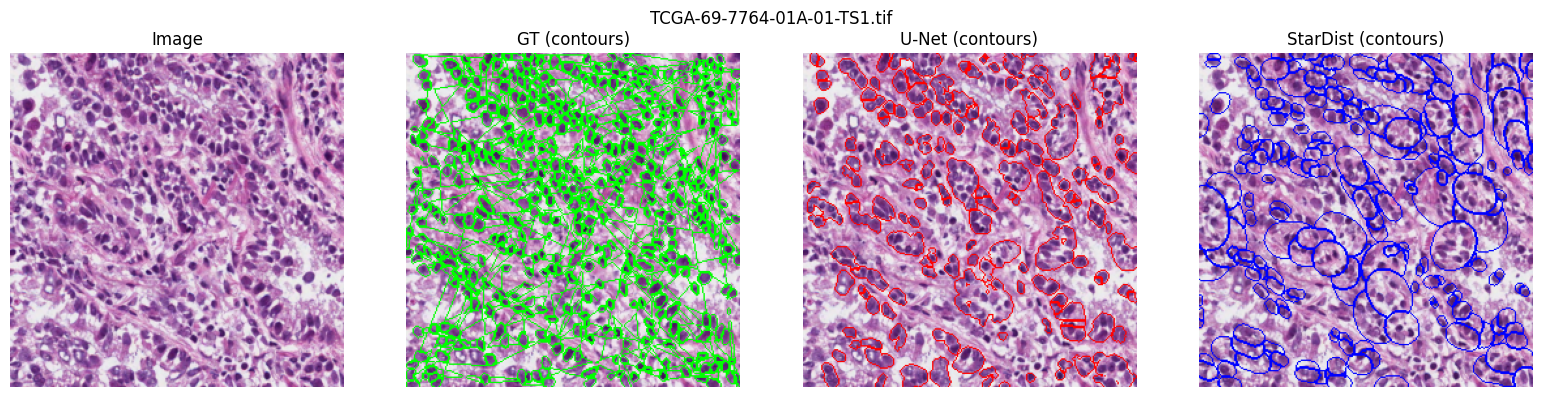

In [20]:
show_panels(img256, gt256, unet_inst=unet_inst, stard_inst=st_inst, title=p.name)


In [18]:
def eval_dataset_resize256(tifs, max_images=None):
    rows = []
    for k, p in enumerate(tifs):
        if max_images is not None and k >= max_images:
            break
        xml = p.with_suffix(".xml")
        img = read_tif_rgb(p)
        gt = monuseg_xml_to_instances(xml, img.shape[0], img.shape[1])
        img256, gt256 = resize_img_and_inst(img, gt, (256,256))

        _, unet_inst = predict_unet_instances(img256, thr=0.5, min_size=20, h=1.5)
        _, st_inst = predict_stardist_instances(img256, prob_thr=0.5, nms_iou_thr=0.3)

        d_u, i_u = dice_iou_binary(unet_inst>0, gt256>0)
        f1_u, TP_u, FP_u, FN_u = f1_instance(unet_inst, gt256, iou_thr=0.5)

        d_s, i_s = dice_iou_binary(st_inst>0, gt256>0)
        f1_s, TP_s, FP_s, FN_s = f1_instance(st_inst, gt256, iou_thr=0.5)

        rows.append({
            "image": p.name,
            "unet_dice": d_u, "unet_iou": i_u, "unet_f1": f1_u, "unet_TP": TP_u, "unet_FP": FP_u, "unet_FN": FN_u,
            "stard_dice": d_s, "stard_iou": i_s, "stard_f1": f1_s, "stard_TP": TP_s, "stard_FP": FP_s, "stard_FN": FN_s,
            "gt_n": int(gt256.max()),
            "unet_n": int(unet_inst.max()),
            "stard_n": int(st_inst.max()),
        })
    return rows


In [ ]:
rows = eval_dataset_resize256(tifs, max_images=None)
len(rows), rows[0]


In [ ]:
import pandas as pd
df = pd.DataFrame(rows)
df.describe()[["unet_dice","unet_iou","unet_f1","stard_dice","stard_iou","stard_f1","gt_n","unet_n","stard_n"]]


In [ ]:
plt.figure(figsize=(8,4))
plt.hist(df["unet_f1"], bins=20, alpha=0.7, label="U-Net F1inst")
plt.hist(df["stard_f1"], bins=20, alpha=0.7, label="StarDist F1inst")
plt.legend()
plt.title("Distribution F1 instance (resize 256)")
plt.show()


In [ ]:
plt.figure(figsize=(8,4))
plt.scatter(df["gt_n"], df["unet_n"], alpha=0.6, label="U-Net")
plt.scatter(df["gt_n"], df["stard_n"], alpha=0.6, label="StarDist")
plt.plot([df["gt_n"].min(), df["gt_n"].max()], [df["gt_n"].min(), df["gt_n"].max()])
plt.legend()
plt.title("Nb instances prédits vs GT (resize 256)")
plt.xlabel("GT instances")
plt.ylabel("Pred instances")
plt.show()
